In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("vgsales.csv")


print(df.shape)
df

(16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [5]:

print(df.isnull().sum())
print(df.duplicated().sum())

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64
0


In [6]:
print(df.dtypes)

Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


In [7]:
df = df.dropna(subset=['Year'])
print(df.isnull().sum())

Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       36
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64


In [8]:
df = df.dropna(subset=['Publisher'])
print(df.isnull().sum())

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


In [9]:
print(df.describe())

               Rank          Year      NA_Sales      EU_Sales      JP_Sales  \
count  16291.000000  16291.000000  16291.000000  16291.000000  16291.000000   
mean    8290.190228   2006.405561      0.265647      0.147731      0.078833   
std     4792.654450      5.832412      0.822432      0.509303      0.311879   
min        1.000000   1980.000000      0.000000      0.000000      0.000000   
25%     4132.500000   2003.000000      0.000000      0.000000      0.000000   
50%     8292.000000   2007.000000      0.080000      0.020000      0.000000   
75%    12439.500000   2010.000000      0.240000      0.110000      0.040000   
max    16600.000000   2020.000000     41.490000     29.020000     10.220000   

        Other_Sales  Global_Sales  
count  16291.000000  16291.000000  
mean       0.048426      0.540910  
std        0.190083      1.567345  
min        0.000000      0.010000  
25%        0.000000      0.060000  
50%        0.010000      0.170000  
75%        0.040000      0.480000  


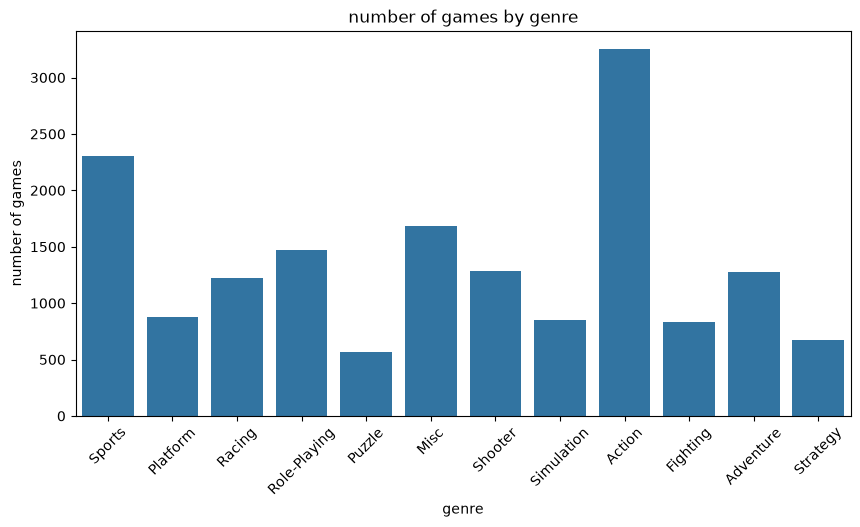

In [10]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x='Genre')

plt.title("number of games by genre")
plt.xlabel("genre")
plt.ylabel("number of games")
plt.xticks(rotation=45)
plt.show()

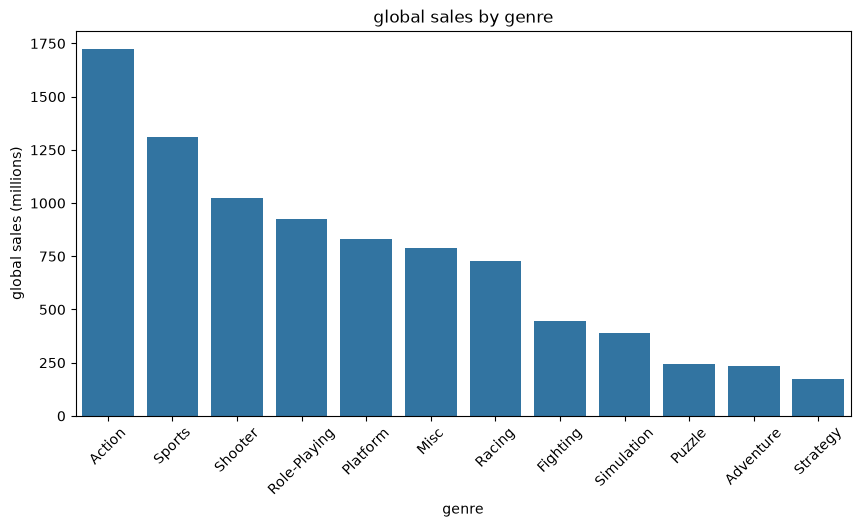

In [11]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=genre_sales.index,
    y=genre_sales.values
)

plt.title("global sales by genre")
plt.xlabel("genre")
plt.ylabel("global sales (millions)")
plt.xticks(rotation=45)
plt.show()

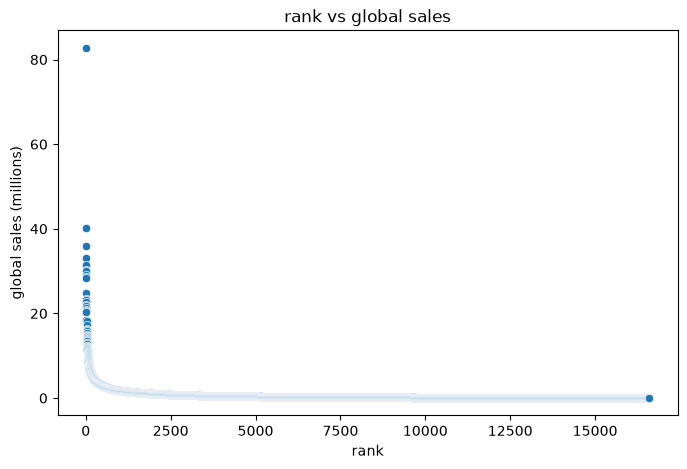

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Rank',
    y='Global_Sales'
)

plt.title("rank vs global sales")
plt.xlabel("rank")
plt.ylabel("global sales (millions)")
plt.show()

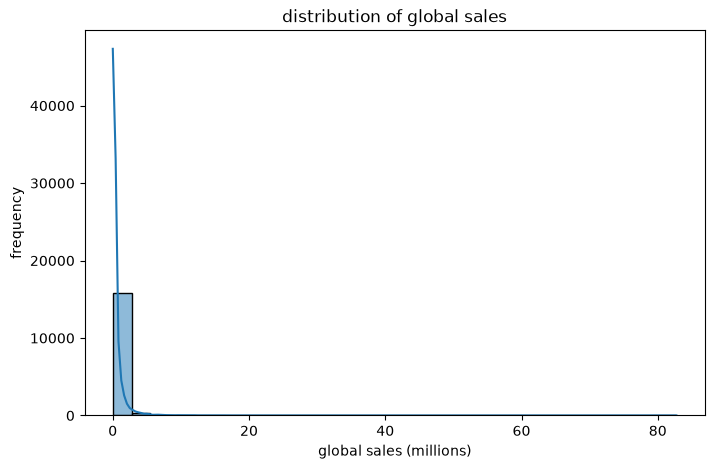

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='Global_Sales',
    bins=30,
    kde=True
)

plt.title("distribution of global sales")
plt.xlabel("global sales (millions)")
plt.ylabel("frequency")
plt.show()

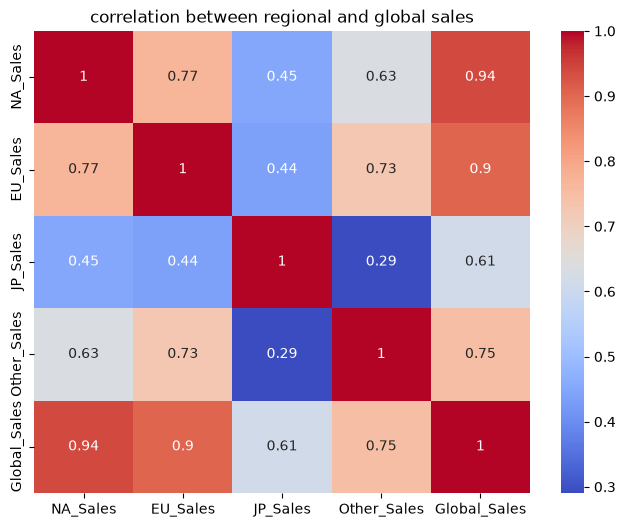

In [14]:
sales_columns = [
    'NA_Sales',
    'EU_Sales',
    'JP_Sales',
    'Other_Sales',
    'Global_Sales'
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[sales_columns].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("correlation between regional and global sales")
plt.show()

In [15]:
top_games = df.sort_values(
    'Global_Sales',
    ascending=False
).head(10)

print(top_games[['Name', 'Platform', 'Genre', 'Global_Sales']])

                        Name Platform         Genre  Global_Sales
0                 Wii Sports      Wii        Sports         82.74
1          Super Mario Bros.      NES      Platform         40.24
2             Mario Kart Wii      Wii        Racing         35.82
3          Wii Sports Resort      Wii        Sports         33.00
4   Pokemon Red/Pokemon Blue       GB  Role-Playing         31.37
5                     Tetris       GB        Puzzle         30.26
6      New Super Mario Bros.       DS      Platform         30.01
7                   Wii Play      Wii          Misc         29.02
8  New Super Mario Bros. Wii      Wii      Platform         28.62
9                  Duck Hunt      NES       Shooter         28.31


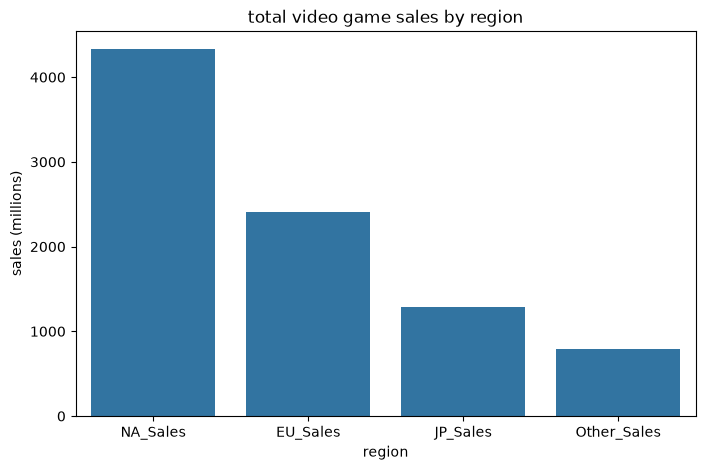

In [16]:
region_sales = df[
    ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
].sum()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("total video game sales by region")
plt.xlabel("region")
plt.ylabel("sales (millions)")
plt.show()